<a href="https://colab.research.google.com/github/manamendraJN/SE4050-Fraud-Detection/blob/TabNet/notebooks/TabNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SE4050 Deep Learning Assignment
TabNet — Credit Card Fraud Detection

IT22608772 - Manamendra J.N

## 1. Setup

In [1]:
!pip install -q pytorch-tabnet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 2.1 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import json, os

from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, f1_score, precision_score, recall_score, accuracy_score
)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

Using device: cuda


## 2. Mount Google Drive and load preprocessed splits

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
PROJECT_DIR = "/content/drive/MyDrive/SE4050-Fraud-Detection"
DATA_DIR    = f"{PROJECT_DIR}/data/processed"
RESULTS_DIR = f"{PROJECT_DIR}/results/tabnet"
CONFIGS_DIR = f"{PROJECT_DIR}/configs"

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(CONFIGS_DIR, exist_ok=True)

train_df = pd.read_csv(f"{DATA_DIR}/train.csv")
val_df   = pd.read_csv(f"{DATA_DIR}/val.csv")
test_df  = pd.read_csv(f"{DATA_DIR}/test.csv")

print("Train:", train_df.shape, "Val:", val_df.shape, "Test:", test_df.shape)
for name, split in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(f"  {name} fraud rate: {split['Class'].mean()*100:.3f}%")

Train: (198608, 31) Val: (42559, 31) Test: (42559, 31)
  train fraud rate: 0.167%
  val fraud rate: 0.167%
  test fraud rate: 0.167%


## 3. Prepare features/target for TabNet

In [5]:
TARGET_COL = "Class"
feature_cols = [c for c in train_df.columns if c != TARGET_COL]
print(f"Using {len(feature_cols)} features:", feature_cols)

def to_xy(df):
    X = df[feature_cols].values.astype(np.float32)
    y = df[TARGET_COL].values.astype(np.int64)
    return X, y

X_train, y_train = to_xy(train_df)
X_val,   y_val   = to_xy(val_df)
X_test,  y_test  = to_xy(test_df)

print("Shapes:", X_train.shape, X_val.shape, X_test.shape)

Using 30 features: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount_log']
Shapes: (198608, 30) (42559, 30) (42559, 30)


## 4. Define and train TabNet (tuned configuration)

Changes from the original baseline run, based on the diagnosis that ~9 fraud cases were being confidently misclassified as normal:

| Parameter | Baseline | Tuned | Why |
|---|---|---|---|
| `n_d`, `n_a` | 16 | 24 | More model capacity to pick up subtler fraud patterns |
| `n_steps` | 4 | 5 | One extra decision step to combine more feature evidence |
| `gamma` | 1.3 | 1.1 | Lower = more feature re-use across steps, helps catch cases needing multiple weak signals combined |
| `lr` | 2e-2 | 1e-2 | Baseline's val_auc curve was noisy/unstable epoch-to-epoch; a gentler LR should stabilize training |
| `weights` | `1` (auto-balance) | `{0:1, 1:5}` | Push harder on the fraud class specifically, beyond the library's default auto-balancing |
| `max_epochs` / `patience` | 150 / 20 | 250 / 30 | Lower LR needs more epochs to converge; more patience avoids stopping too early |



In [6]:
tabnet_params = dict(
    n_d=24,
    n_a=24,
    n_steps=5,
    gamma=1.1,
    lambda_sparse=1e-3,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=1e-2),
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    scheduler_params=dict(step_size=15, gamma=0.9),
    mask_type="sparsemax",
    seed=RANDOM_SEED,
    device_name=DEVICE,
)

clf = TabNetClassifier(**tabnet_params)

clf.fit(
    X_train=X_train, y_train=y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    eval_name=["train", "val"],
    eval_metric=["auc"],
    max_epochs=250,
    patience=30,
    batch_size=2048,
    virtual_batch_size=256,
    weights={0: 1, 1: 5},  # push harder on the minority fraud class than auto-balance alone
    num_workers=0,
    drop_last=False,
)

/usr/local/lib/python3.13/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.05227 | train_auc: 0.92599 | val_auc: 0.89495 |  0:00:12s
epoch 1  | loss: 0.01812 | train_auc: 0.95767 | val_auc: 0.947   |  0:00:22s
epoch 2  | loss: 0.01659 | train_auc: 0.96813 | val_auc: 0.94897 |  0:00:34s
epoch 3  | loss: 0.0139  | train_auc: 0.97523 | val_auc: 0.9564  |  0:00:44s
epoch 4  | loss: 0.01385 | train_auc: 0.98031 | val_auc: 0.96628 |  0:00:54s
epoch 5  | loss: 0.01273 | train_auc: 0.98341 | val_auc: 0.95879 |  0:01:05s
epoch 6  | loss: 0.01434 | train_auc: 0.97329 | val_auc: 0.95993 |  0:01:16s
epoch 7  | loss: 0.01319 | train_auc: 0.98047 | val_auc: 0.94927 |  0:01:26s
epoch 8  | loss: 0.01137 | train_auc: 0.98696 | val_auc: 0.96159 |  0:01:37s
epoch 9  | loss: 0.01201 | train_auc: 0.98746 | val_auc: 0.96648 |  0:01:47s
epoch 10 | loss: 0.01141 | train_auc: 0.98919 | val_auc: 0.96543 |  0:01:58s
epoch 11 | loss: 0.01154 | train_auc: 0.98888 | val_auc: 0.9599  |  0:02:09s
epoch 12 | loss: 0.01005 | train_auc: 0.98933 | val_auc: 0.96721 |  0:02:18s

/usr/local/lib/python3.13/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


## 5. Training curves

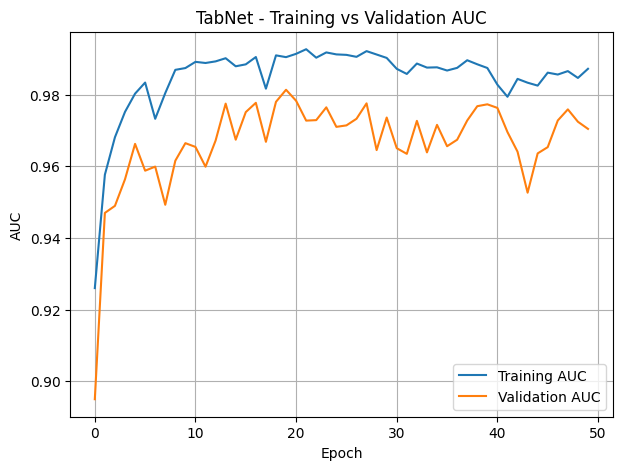

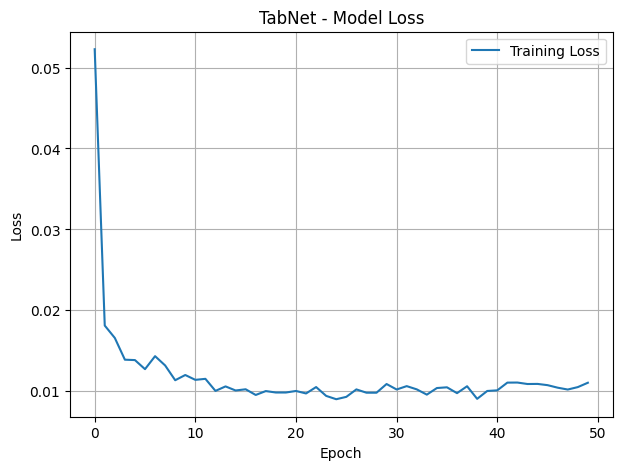

In [7]:
history = clf.history

plt.figure(figsize=(7,5))
plt.plot(history["train_auc"], label="Training AUC")
plt.plot(history["val_auc"], label="Validation AUC")
plt.title("TabNet - Training vs Validation AUC")
plt.xlabel("Epoch"); plt.ylabel("AUC"); plt.legend(); plt.grid(True)
plt.savefig(f"{RESULTS_DIR}/training_auc.png", dpi=150, bbox_inches="tight")
plt.show()

plt.figure(figsize=(7,5))
plt.plot(history["loss"], label="Training Loss")
plt.title("TabNet - Model Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.grid(True)
plt.savefig(f"{RESULTS_DIR}/training_loss.png", dpi=150, bbox_inches="tight")
plt.show()

## 5b. Threshold tuning

Best threshold (max F1 on validation set): 0.3850
Validation F1 at this threshold: 0.8030


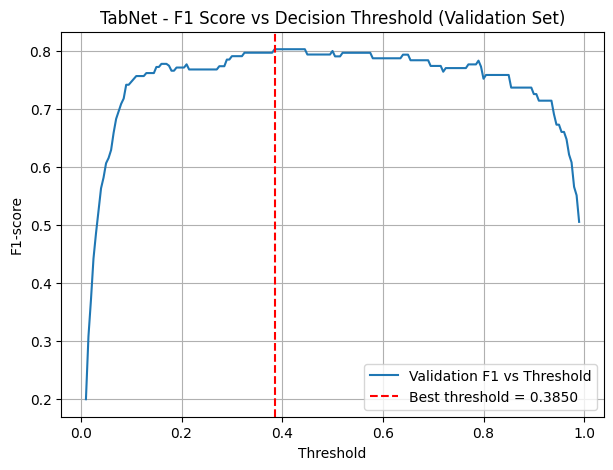


Note: BEST_THRESHOLD was selected using only the validation set.
It is applied to the test set below for final, unbiased reporting.


In [8]:
from sklearn.metrics import f1_score as _f1

y_val_proba = clf.predict_proba(X_val)[:, 1]

thresholds = np.linspace(0.01, 0.99, 197)
f1_scores = [_f1(y_val, (y_val_proba >= t).astype(int)) for t in thresholds]

best_idx = int(np.argmax(f1_scores))
BEST_THRESHOLD = thresholds[best_idx]
best_val_f1 = f1_scores[best_idx]

print(f"Best threshold (max F1 on validation set): {BEST_THRESHOLD:.4f}")
print(f"Validation F1 at this threshold: {best_val_f1:.4f}")

plt.figure(figsize=(7,5))
plt.plot(thresholds, f1_scores, label="Validation F1 vs Threshold")
plt.axvline(BEST_THRESHOLD, color="red", linestyle="--",
            label=f"Best threshold = {BEST_THRESHOLD:.4f}")
plt.title("TabNet - F1 Score vs Decision Threshold (Validation Set)")
plt.xlabel("Threshold"); plt.ylabel("F1-score"); plt.legend(); plt.grid(True)
plt.savefig(f"{RESULTS_DIR}/threshold_tuning.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nNote: BEST_THRESHOLD was selected using only the validation set.\n"
      "It is applied to the test set below for final, unbiased reporting.")

## 6. Evaluation on the held-out test set

In [9]:
y_proba = clf.predict_proba(X_test)[:, 1]
y_pred  = (y_proba >= BEST_THRESHOLD).astype(int)  # tuned threshold 0.5

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
auc  = roc_auc_score(y_test, y_proba)

print(f"Decision threshold used: {BEST_THRESHOLD:.4f}")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"ROC-AUC:   {auc:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=["Normal", "Fraud"]))


Decision threshold used: 0.3850
Accuracy:  0.9993
Precision: 0.8182
Recall:    0.7606
F1-score:  0.7883
ROC-AUC:   0.9500

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     42488
       Fraud       0.82      0.76      0.79        71

    accuracy                           1.00     42559
   macro avg       0.91      0.88      0.89     42559
weighted avg       1.00      1.00      1.00     42559



## 6b. Error analysis — probability distribution and misclassified cases

Diagnostic from earlier: with the baseline model, ~9 fraud cases in validation were confidently predicted as normal (probability near 0). This section checks whether the tuned configuration reduced that, and inspects which specific transactions remain hardest to catch.

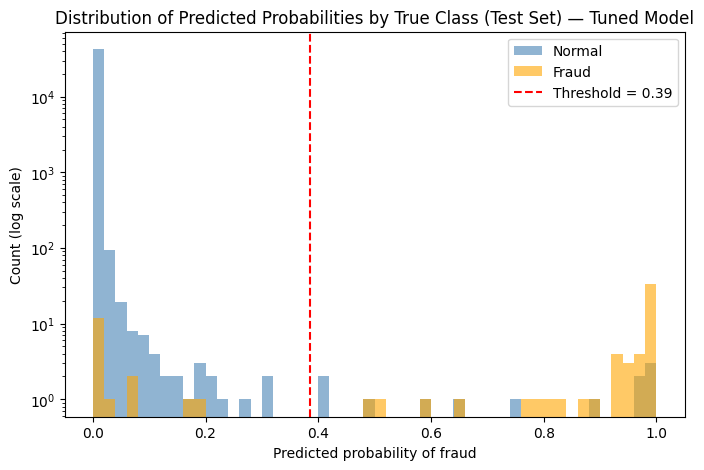

Missed frauds (false negatives): 17 out of 71 total frauds
False alarms (false positives): 12 out of 42488 total normal txns

Missed fraud cases (sorted by how confidently they were missed):


,Time,Amount_log,predicted_proba
3592,0.129200,-1.511867,0.000002
20799,-1.061039,-1.487218,0.000017
9771,-0.507269,-1.564406,0.000100
47,-0.575858,1.904364,0.000123
0,1.250766,2.321729,0.000152
31964,-0.407702,0.166780,0.000670
31210,-0.465235,0.406448,0.001559
3408,-0.569836,1.579155,0.001807
1829,-0.884101,-1.564406,0.005190
4049,-0.162447,1.786167,0.009555


In [10]:
# Probability distribution by true class (test set) — compare against the baseline run's plot
plt.figure(figsize=(8,5))
plt.hist(y_proba[y_test==0], bins=50, alpha=0.6, label="Normal", color="steelblue", log=True)
plt.hist(y_proba[y_test==1], bins=50, alpha=0.6, label="Fraud", color="orange", log=True)
plt.axvline(BEST_THRESHOLD, color="red", linestyle="--", label=f"Threshold = {BEST_THRESHOLD:.2f}")
plt.title("Distribution of Predicted Probabilities by True Class (Test Set) — Tuned Model")
plt.xlabel("Predicted probability of fraud"); plt.ylabel("Count (log scale)")
plt.legend()
plt.savefig(f"{RESULTS_DIR}/probability_distribution_tuned.png", dpi=150, bbox_inches="tight")
plt.show()

# Missed frauds: true fraud, predicted as normal, with low confidence
test_df_reset = test_df.reset_index(drop=True)
missed_fraud_mask = (y_test == 1) & (y_pred == 0)
false_alarm_mask  = (y_test == 0) & (y_pred == 1)

print(f"Missed frauds (false negatives): {missed_fraud_mask.sum()} out of {(y_test==1).sum()} total frauds")
print(f"False alarms (false positives): {false_alarm_mask.sum()} out of {(y_test==0).sum()} total normal txns")

missed_frauds = test_df_reset[missed_fraud_mask].copy()
missed_frauds["predicted_proba"] = y_proba[missed_fraud_mask]
print("\nMissed fraud cases (sorted by how confidently they were missed):")
missed_frauds.sort_values("predicted_proba")[["Time", "Amount_log", "predicted_proba"]].head(15)

### Confusion matrix, ROC curve, and precision-recall curve

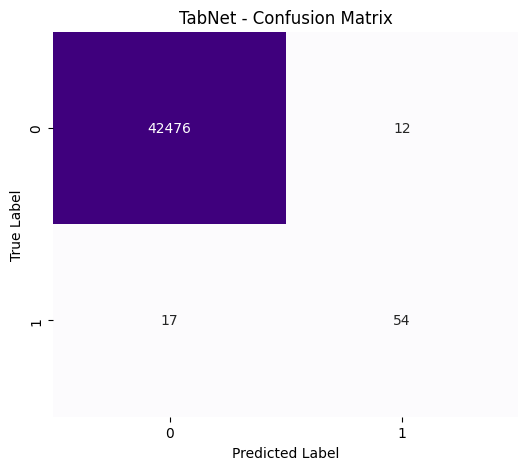

In [11]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples", cbar=False)
plt.title("TabNet - Confusion Matrix")
plt.xlabel("Predicted Label"); plt.ylabel("True Label")
plt.savefig(f"{RESULTS_DIR}/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

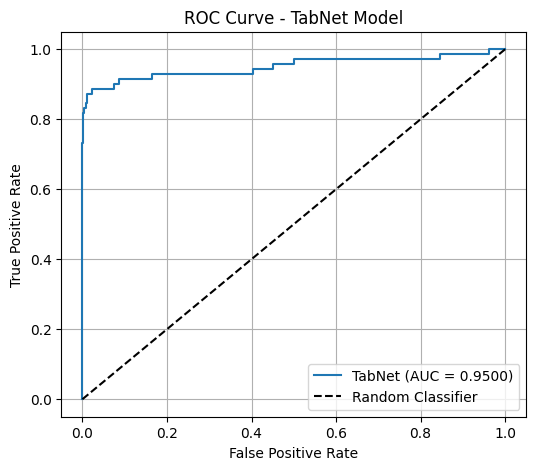

In [12]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"TabNet (AUC = {auc:.4f})")
plt.plot([0,1],[0,1],"k--", label="Random Classifier")
plt.title("ROC Curve - TabNet Model")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.legend(); plt.grid(True)
plt.savefig(f"{RESULTS_DIR}/roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

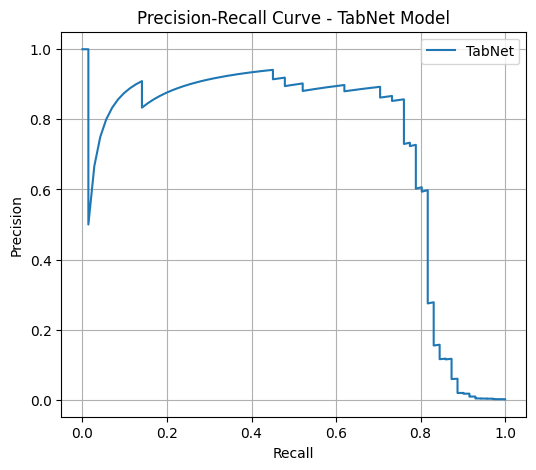

In [13]:
precision, recall, _ = precision_recall_curve(y_test, y_proba)
plt.figure(figsize=(6,5))
plt.plot(recall, precision, label="TabNet")
plt.title("Precision-Recall Curve - TabNet Model")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.legend(); plt.grid(True)
plt.savefig(f"{RESULTS_DIR}/pr_curve.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Save metrics, model, and config

In [14]:

from sklearn.metrics import auc as _auc_fn

precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_proba)
pr_auc = _auc_fn(recall_curve, precision_curve)

metrics = {
    "model": "TabNet",
    "accuracy": acc,
    "precision": prec,
    "recall": rec,
    "f1_score": f1,
    "roc_auc": auc,
    "pr_auc": pr_auc,
    "threshold": BEST_THRESHOLD,
    "random_seed": RANDOM_SEED,
}
pd.DataFrame([metrics]).to_csv(f"{RESULTS_DIR}/metrics.csv", index=False)
print(metrics)

config_to_save = {k: (v if isinstance(v, (int, float, str, bool)) else str(v))
                   for k, v in tabnet_params.items()}
config_to_save["max_epochs"] = 250
config_to_save["patience"] = 30
config_to_save["batch_size"] = 2048
config_to_save["virtual_batch_size"] = 256
config_to_save["class_weights"] = {0: 1, 1: 5}
config_to_save["random_seed"] = RANDOM_SEED
config_to_save["decision_threshold"] = BEST_THRESHOLD

with open(f"{CONFIGS_DIR}/tabnet_config.json", "w") as f:
    json.dump(config_to_save, f, indent=2)
print(f"Saved config to {CONFIGS_DIR}/tabnet_config.json")

clf.save_model(f"{RESULTS_DIR}/tabnet_model")
print(f"Saved model to {RESULTS_DIR}/tabnet_model.zip")


{'model': 'TabNet', 'accuracy': 0.9993185930120538, 'precision': 0.8181818181818182, 'recall': 0.7605633802816901, 'f1_score': 0.7883211678832117, 'roc_auc': np.float64(0.9499716241338069), 'pr_auc': np.float64(0.7204386477400657), 'threshold': np.float64(0.385), 'random_seed': 42}
Saved config to /content/drive/MyDrive/SE4050-Fraud-Detection/configs/tabnet_config.json
Successfully saved model at /content/drive/MyDrive/SE4050-Fraud-Detection/results/tabnet/tabnet_model.zip
Saved model to /content/drive/MyDrive/SE4050-Fraud-Detection/results/tabnet/tabnet_model.zip
